# La imagen como tensor: canales, escala y calidad de representación

En este ejercicio se analiza una imagen digital como un arreglo numérico y como un tensor. Se estudian sus dimensiones, píxeles, canales de color, tipos de datos, normalización, resolución y formato requerido por PyTorch

## Preparación del entorno

Se importan las librerías que se utilizarán para cargar, transformar, visualizar y convertir la imagen en un tensor

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)

OpenCV: 5.0.0
NumPy: 2.4.6
PyTorch: 2.14.0


## Elección de la imagen

Esta imagen es propia, la tomé con mi celular en un taller de bordado de mascotas navideñas

### Lectura de la imagen con OpenCV

`cv2.imread()` devuelve un arreglo NumPy con la imagen en el orden de canales BGR

In [2]:
# Cargar la imagen desde el archivo; OpenCV la devuelve en formato BGR.
imagen = cv2.imread("data/lupe_navidad.jpg")

In [3]:
type(imagen)

numpy.ndarray

## Carga y representación numérica de la imagen

In [4]:
print("Tipo de la imagen:", type(imagen))
print("Forma de la imagen:", imagen.shape)
print("Número de dimensiones:", imagen.ndim)
print("Tamaño total:", imagen.size)
print("Tipo de datos:", imagen.dtype)

Tipo de la imagen: <class 'numpy.ndarray'>
Forma de la imagen: (2858, 2252, 3)
Número de dimensiones: 3
Tamaño total: 19308648
Tipo de datos: uint8


Shape muestra el tamaño de la imagen en píxeles y el número de canales. En este caso, la imagen tiene 3 canales (RGB) y un tamaño de 2858x2252 píxeles.
Size es el número total de elementos en la imagen, que es el producto de las dimensiones (2858 * 2252 * 3).
ndim indica el número de dimensiones de la imagen, que es 3 en este caso (alto, ancho y canales)

## Píxeles y valores numéricos

In [5]:
# Seleccionar dos píxeles usando coordenadas [fila, columna].
pixel_1 = imagen[100, 100]
pixel_2 = imagen[200, 300]

print(pixel_1)
print(pixel_2)

[201 209 208]
[178 184 113]


In [6]:
print(type(pixel_1))
print(pixel_1.shape)
print(pixel_1.dtype)

<class 'numpy.ndarray'>
(3,)
uint8


In [7]:
print(pixel_1[0])
print(pixel_1[1])
print(pixel_1[2])

201
209
208


Un píxel de una imagen a color no está representado por un único número, sino por un valor para cada canal. En una imagen RGB, esos valores corresponden a rojo (R), verde (G) y azul (B); en la imagen recién cargada con OpenCV corresponden a azul (B), verde (G) y rojo (R)

Con `dtype=uint8`, cada componente puede tomar valores entre 0 y 255: 0 representa ausencia de intensidad y 255 representa la intensidad máxima

## Investigar los canales

Se separan los tres canales para observar la contribución espacial de cada componente de color.

In [8]:
# En una imagen BGR: canal 0 = azul, canal 1 = verde y canal 2 = rojo.
canal_0 = imagen[:, :, 0]
canal_1 = imagen[:, :, 1]
canal_2 = imagen[:, :, 2]

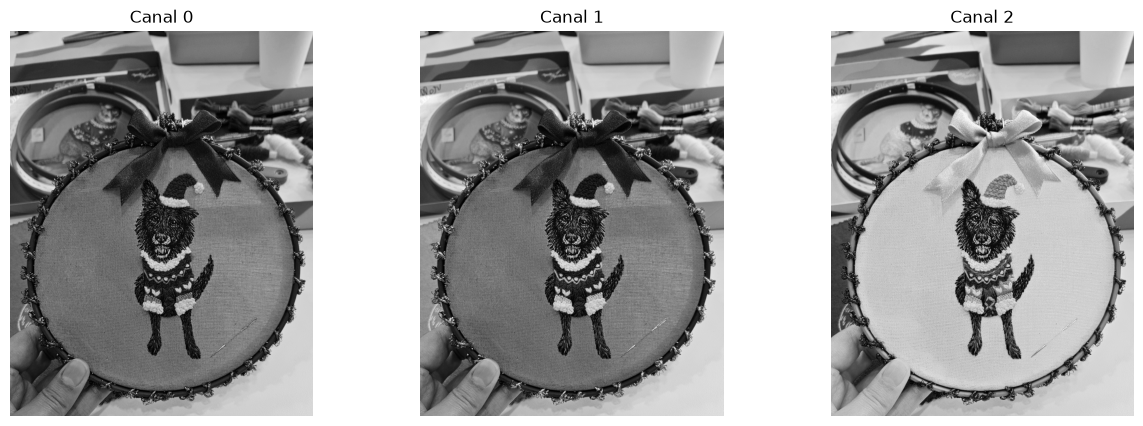

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (ax, canal) in enumerate(zip(axes, [canal_0, canal_1, canal_2])):
    ax.imshow(canal, cmap="gray")
    ax.set_title(f"Canal {i}")
    ax.axis("off")

Cada panel muestra un canal como una imagen en escala de grises. Las zonas claras indican mayor intensidad del canal y las zonas oscuras, menor intensidad

Como la imagen fue cargada con OpenCV, el canal 0 es azul, el canal 1 es verde y el canal 2 es rojo. La visualización en gris permite comparar intensidades sin mezclar los colores de los demás canales

## Imagen de un solo canal frente a imagen con un único color activo

Primero se crearán imágenes de tres canales en las que solo uno conservará sus intensidades originales. Esto permite diferenciar un canal aislado de una imagen monocromática

In [10]:
ceros = np.zeros_like(canal_0)
print(ceros.shape)
print(ceros.min(), ceros.max())

(2858, 2252)
0 0


In [11]:
solo_azul_bgr = cv2.merge([
    canal_0,
    ceros,
    ceros
])

solo_verde_bgr = cv2.merge([
    ceros,
    canal_1,
    ceros
])

solo_rojo_bgr = cv2.merge([
    ceros,
    ceros,
    canal_2
])

In [12]:
solo_azul_rgb = cv2.cvtColor(solo_azul_bgr, cv2.COLOR_BGR2RGB)
solo_verde_rgb = cv2.cvtColor(solo_verde_bgr, cv2.COLOR_BGR2RGB)
solo_rojo_rgb = cv2.cvtColor(solo_rojo_bgr, cv2.COLOR_BGR2RGB)

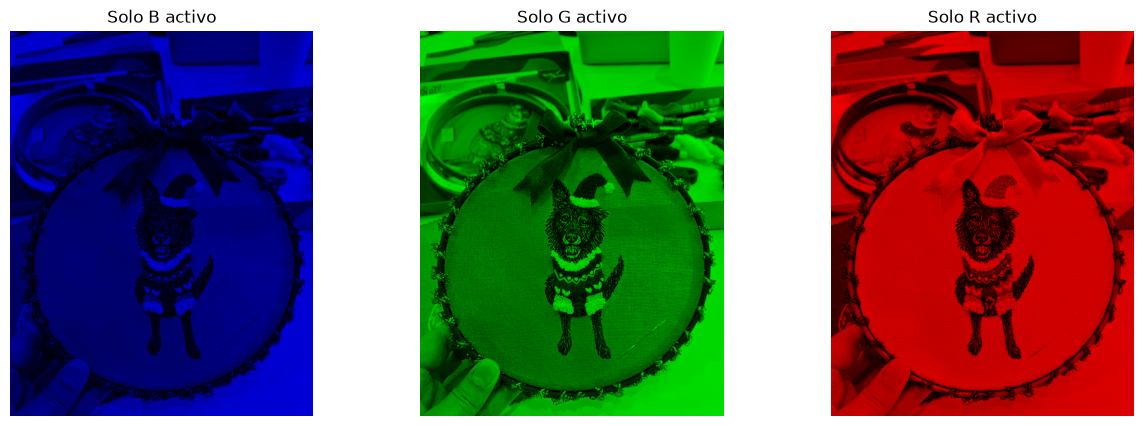

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(solo_azul_rgb)
ax[0].set_title("Solo B activo")

ax[1].imshow(solo_verde_rgb)
ax[1].set_title("Solo G activo")

ax[2].imshow(solo_rojo_rgb)
ax[2].set_title("Solo R activo")

for a in ax:
    a.axis("off")

plt.show()

## Orden BGR y RGB

OpenCV carga imágenes como BGR, mientras que Matplotlib espera RGB para mostrarlas con colores correctos

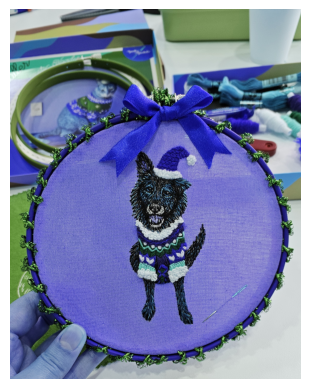

In [14]:
# La visualización directa interpreta el arreglo BGR como si fuera RGB.
plt.imshow(imagen)
plt.axis("off")
plt.show()

OpenCV utiliza el orden de canales BGR (azul, verde, rojo), mientras que Matplotlib interpreta los arreglos de color como RGB (rojo, verde, azul). Por eso la visualización directa puede intercambiar los colores rojo y azul

La conversión siguiente reorganiza los canales sin cambiar sus intensidades

In [15]:
# Reordenar los canales de BGR a RGB para visualización y procesamiento posterior.
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

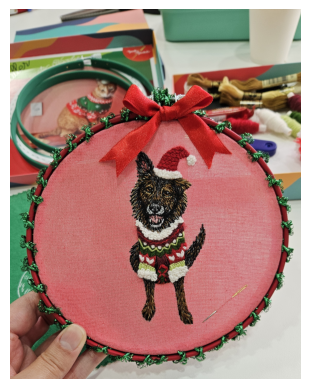

In [16]:
plt.imshow(imagen_rgb)
plt.axis("off")
plt.show()

In [17]:
imagen.min()

np.uint8(0)

In [18]:
imagen.max()

np.uint8(255)

## Reconstrucción de la imagen completa

Si se conservan los tres canales y se combinan en el mismo orden, el arreglo reconstruido debe coincidir con la imagen original

In [19]:
# Combinar los canales en el mismo orden BGR en el que fueron extraídos.
reconstruida = cv2.merge([
    canal_0,
    canal_1,
    canal_2
])

print("Original:", imagen.shape)
print("Reconstruida:", reconstruida.shape)

# La igualdad elemento a elemento comprueba que no se perdió información.
print(
    "¿Son iguales?",
    np.array_equal(imagen, reconstruida)
)

Original: (2858, 2252, 3)
Reconstruida: (2858, 2252, 3)
¿Son iguales? True


Al separar una imagen en sus canales no se pierde información mientras se conserven todos ellos. `cv2.merge()` vuelve a combinar los canales en el orden indicado; por eso la reconstrucción coincide con el arreglo original cuando se usa el mismo orden BGR

## Convertir a escala de grises

Una imagen en escala de grises conserva una sola intensidad por píxel. Se usará la conversión de OpenCV para comparar esa intensidad con el promedio simple de los canales

In [20]:
# Convertir de BGR a una imagen de un solo canal de intensidad.
imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

In [21]:
imagen_gris.shape

(2858, 2252)

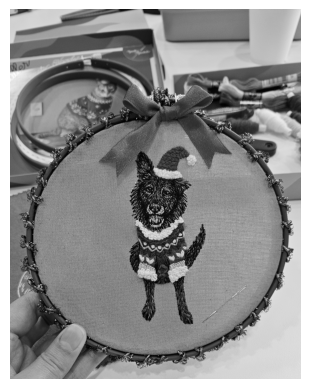

In [22]:
plt.imshow(imagen_gris, cmap="gray")
plt.axis("off")
plt.show()

In [23]:
y = 100
x = 100

print("BGR:", imagen[y, x])
print("Gris:", imagen_gris[y, x])

print("Promedio simple:", imagen[y, x].mean())

BGR: [201 209 208]
Gris: 208
Promedio simple: 206.0


La conversión a escala de grises produce una nueva medida de intensidad o luminancia a partir de los componentes de color. OpenCV utiliza una combinación ponderada porque los componentes no contribuyen igualmente a la luminancia percibida. Por eso eso el promedio simple de los tres canales no es igual a la conversión a escala de grises

## Tipo de dato y rango de intensidades

In [24]:
print("B:", canal_0.min(), canal_0.max())
print("G:", canal_1.min(), canal_1.max())
print("R:", canal_2.min(), canal_2.max())

B: 0 255
G: 0 255
R: 0 255


uint8 significa entero sin signo de 8 bits. Ocho bits permiten:

$$
2^8=256
$$

valores diferentes:

$$0,\ldots,255$$

## Normalizar intensidades

La normalización transforma los valores `uint8` del intervalo `[0, 255]` al intervalo `[0, 1]`, normalmente requerido por modelos de aprendizaje profundo

In [25]:
# Convertir a float32 y escalar cada intensidad al intervalo [0, 1].
imagen_normalizada = imagen_rgb.astype(np.float32) / 255.0

In [26]:
print(imagen_rgb.dtype)
print(imagen_rgb.min())
print(imagen_rgb.max())

uint8
0
255


In [27]:
print(imagen_normalizada.dtype)
print(imagen_normalizada.min())
print(imagen_normalizada.max())

float32
0.0
1.0


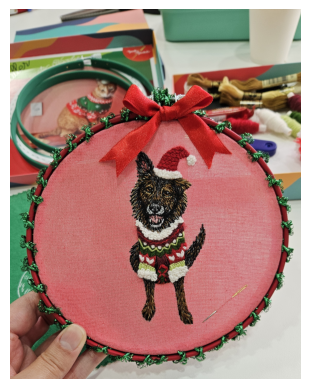

In [28]:
plt.imshow(imagen_normalizada)
plt.axis("off")
plt.show()

Al normalizar cambian el tipo de dato y la escala numérica, pero no la estructura espacial de la imagen ni las relaciones relativas entre sus intensidades. La imagen sigue teniendo las mismas dimensiones y canales

## Resolución y calidad de representación

Se comparará la misma imagen con distintas resoluciones para observar el compromiso entre detalle visual, memoria y costo computacional

In [29]:
# Redimensionar manteniendo tres canales, pero reduciendo el número de píxeles.
img_224 = cv2.resize(imagen_rgb, (224, 224))
img_64 = cv2.resize(imagen_rgb, (64, 64))
img_16 = cv2.resize(imagen_rgb, (16, 16))

print("Original:", imagen_rgb.shape)
print("224:", img_224.shape)
print("64:", img_64.shape)
print("16:", img_16.shape)

Original: (2858, 2252, 3)
224: (224, 224, 3)
64: (64, 64, 3)
16: (16, 16, 3)


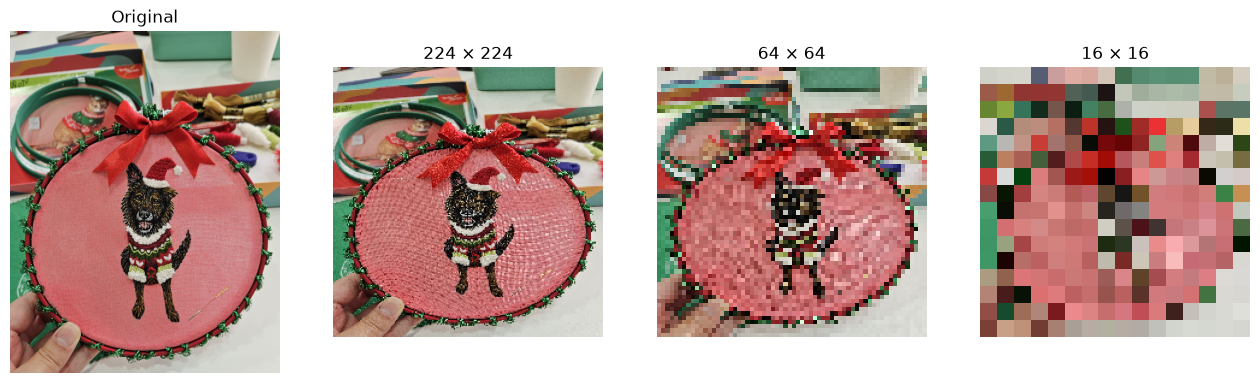

In [30]:
fig, ax = plt.subplots(1, 4, figsize=(16, 5))

imagenes = [
    imagen_rgb,
    img_224,
    img_64,
    img_16
]

titulos = [
    "Original",
    "224 × 224",
    "64 × 64",
    "16 × 16"
]

for a, img, titulo in zip(ax, imagenes, titulos):
    a.imshow(img)
    a.set_title(titulo)
    a.axis("off")

plt.show()

Cada píxel es una muestra espacial de la escena. Reducir la resolución significa representar la misma escena con menos muestras: disminuyen la memoria y el costo computacional, pero también se pierde detalle y pueden desaparecer estructuras pequeñas

## Tamaño en memoria

El consumo de memoria depende del número de elementos y de los bytes utilizados para almacenar cada elemento

In [31]:
print(
    "Original uint8:",
    imagen_rgb.nbytes
)

print(
    "Normalizada float32:",
    imagen_normalizada.nbytes
)

print(
    "Bytes por elemento uint8:",
    imagen_rgb.itemsize
)

print(
    "Bytes por elemento float32:",
    imagen_normalizada.itemsize
)

print(
    "MB Original uint8:",
    imagen_rgb.nbytes / (1024 * 1024)
)

print(
    "MB Normalizada float32:",
    imagen_normalizada.nbytes / (1024 * 1024)
)

Original uint8: 19308648
Normalizada float32: 77234592
Bytes por elemento uint8: 1
Bytes por elemento float32: 4
MB Original uint8: 18.414161682128906
MB Normalizada float32: 73.65664672851562


In [32]:
memoria = (
    imagen_rgb.shape[0]
    * imagen_rgb.shape[1]
    * imagen_rgb.shape[2]
    * imagen_rgb.itemsize
)

print("Calculada:", memoria)
print("nbytes:", imagen_rgb.nbytes)

Calculada: 19308648
nbytes: 19308648


Con las mismas dimensiones, la versión `float32` ocupa aproximadamente cuatro veces la memoria de la versión `uint8`: cada elemento requiere 4 bytes en lugar de 1. La normalización mejora la representación numérica para muchos modelos, pero puede aumentar el consumo de memoria

## Tensor

Una imagen puede considerarse un tensor de tres dimensiones: alto, ancho y canales. En este punto se añadirá una dimensión de lote para mostrar la diferencia entre una imagen individual y un conjunto de imágenes

In [33]:
imagen_normalizada.shape

(2858, 2252, 3)

In [34]:
# Añadir una dimensión al inicio para representar un lote de una imagen.
tensor = np.expand_dims(imagen_normalizada, axis=0)

In [35]:
tensor.shape

(1, 2858, 2252, 3)

## Tensor en PyTorch

Se convertirá el arreglo de NumPy a un tensor de PyTorch para utilizar las operaciones habituales del aprendizaje profundo

In [36]:
# Crear un tensor de PyTorch a partir del arreglo normalizado de NumPy.
tensor_pytorch = torch.from_numpy(imagen_normalizada)

In [37]:
tensor_pytorch.shape

torch.Size([2858, 2252, 3])

Un tensor es una estructura multidimensional para representar y operar con datos numéricos. NumPy también utiliza arreglos multidimensionales, pero PyTorch proporciona operaciones diseñadas para Deep Learning, incluyendo cálculo automático de gradientes y ejecución sobre aceleradores compatibles

## Orden de dimensiones para PyTorch

NumPy y Matplotlib suelen trabajar con imágenes en formato $H \times W \times C$. PyTorch utiliza habitualmente $C \times H \times W$, por lo que se deben reorganizar los ejes antes de alimentar una imagen a muchos modelos

In [38]:
# Reordenar de HWC a CHW sin cambiar el número ni los valores de los elementos.
tensor_chw = tensor_pytorch.permute(2, 0, 1)

print("Antes:", tensor_pytorch.shape)
print("Después:", tensor_chw.shape)

Antes: torch.Size([2858, 2252, 3])
Después: torch.Size([3, 2858, 2252])


In [39]:
print("Elementos antes:", tensor_pytorch.numel())
print("Elementos después:", tensor_chw.numel())

print("Mínimo:", tensor_chw.min())
print("Máximo:", tensor_chw.max())

Elementos antes: 19308648
Elementos después: 19308648
Mínimo: tensor(0.)
Máximo: tensor(1.)


`permute()` solo reorganiza los ejes; no normaliza ni modifica las intensidades. La imagen pasa de $H \times W \times C$ a $C \times H \times W$, que es el formato utilizado habitualmente por las capas convolucionales de PyTorch.


La comprobación de `numel()`, mínimo y máximo confirma que se conservan la cantidad de elementos y el rango de valores

Este ejercicio permitió identificar dos errores comunes en el manejo de imágenes como arreglos numéricos. El primero ocurre al visualizar directamente una imagen cargada con OpenCV usando Matplotlib sin convertir el orden de canales: como OpenCV devuelve BGR y Matplotlib espera RGB, la imagen se muestra con los canales rojo y azul intercambiados, aunque los datos numéricos no estén corrompidos. El segundo error consiste en asumir que la conversión a escala de grises equivale al promedio simple de los tres canales de color; en realidad, OpenCV aplica una combinación ponderada que refleja la sensibilidad perceptual del ojo humano a cada componente de color, por lo que ambos cálculos producen resultados distintos